# Topic 5 Neural Networks

In [58]:
import numpy as np
from PIL import Image
import os

In [39]:
# Activation function (Sigmoid)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

### Step 1.
Programar una capa de entrada, una capa oculta con una neurona y una capa de salida.

In [ ]:
# Load the data
input = np.random.random(10)       # Input data

# Initialize the NN parameters
weights = np.random.random(10)     # Weights
bias = np.random.random()          # Bias

In [75]:
# Output of the neuron
output = sigmoid(np.dot(input, weights) + bias)
print("Initial output:", output)

# Gradient descent (simplified)
learning_rate = 0.01
target = 0.5  # Target output
error = output - target
weights -= learning_rate * error * input
bias -= learning_rate * error

output = sigmoid(np.dot(input, weights) + bias)
print("Output after training:", output)

Initial output: 0.9520386762090629
Output after training: 0.9510039545598606


### Step 2
Probar la efectividad de la NN con imágenes sencillas

In [193]:
# Load the images
img_path = 'dataset/1/fighter'  # Base path to the dataset

classes = {'f35': 0, 'su57': 1}  # Classes in the dataset
images = []  # List to store image data
labels = []  # List to store corresponding labels

for class_idx in classes:
    for img_file in os.listdir(os.path.join(img_path, class_idx)):
        if img_file.lower().endswith(('.jpeg', '.jpg', 'png')):
            img_file = os.path.join(img_path, class_idx, img_file)  # Full path to the image
            img = Image.open(img_file)  # Load an image
            img = img.convert('RGB')  # Ensure it's in RGB format
            img = img.resize((128, 128))  # Resize the image to a fixed size
            img_array = np.array(img) / 255.0  # Normalize pixel values to [0, 1]
            images.append(img_array)  # Store the image array
            labels.append(classes.get(class_idx))  # Store the corresponding label

print(np.array(images).shape)  # Should print (num_images, 128, 128, 3)
print(np.array(labels).shape)  # Should print (num_images,)

(546, 128, 128, 3)
(546,)


In [194]:
# Set the training and test batches randomly
shuffled_indices = np.random.permutation(len(images)) # Shuffle the indices of the dataset
images = np.array(images)[shuffled_indices]
labels = np.array(labels)[shuffled_indices]
train_images = np.array(images[:int(0.8 * len(images))])
train_labels = np.array(labels[:int(0.8 * len(labels))])
test_images = np.array(images[int(0.8 * len(images)):])
test_labels = np.array(labels[int(0.8 * len(labels)):])

In [96]:
# Use of the NN on one image (simplified)
def simple_nn(image):
    # Flatten the image
    input_vector = image.flatten()
    
    # Initialize random weights and bias for demonstration
    weights = np.random.random(input_vector.shape[0])
    bias = np.random.random()

    # Gradient descent (simplified)
    learning_rate = 0.01
    target = test_labels[0]  # Target output for demonstration
    output = sigmoid(np.dot(input_vector, weights) + bias)
    error = output - target
    weights -= learning_rate * error * input_vector
    bias -= learning_rate * error
    
    # Compute the output
    output = sigmoid(np.dot(input_vector, weights) + bias)
    return output

# Test the NN on a sample image
sample_image = test_images[0]  # Take the first image from the test set
nn_output = simple_nn(sample_image)
print("NN output for the sample image:", nn_output)
print("True label for the sample image:", test_labels[0])

NN output for the sample image: 1.0
True label for the sample image: 1


In [124]:
# Training the NN on the training set (simplified)
def train_nn(train_images, train_labels):
    # Initialize random weights and bias for demonstration
    input_size = train_images[0].flatten().shape[0]
    weights = np.random.random(input_size)
    bias = np.random.random()

    loss_history = []  # To store loss values for each epoch

    # Gradient descent (simplified)
    learning_rate = 0.01
    for epoch in range(50):  # Number of epochs
        for img, label in zip(train_images, train_labels):
            input_vector = img.flatten()
            output = sigmoid(np.dot(input_vector, weights) + bias)
            error = output - label
            weights -= learning_rate * error * input_vector
            bias -= learning_rate * error

            # Extract the loss function (simplified)
            loss = -(1/len(train_images)) * np.sum(label * np.log(output) + (1 - label) * np.log(1 - output))
            loss_history.append(loss)

    return weights, bias, loss_history

# Train the NN
weights, bias, loss_history = train_nn(train_images, train_labels)

/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_22265/2692749187.py:21: RuntimeWarning: divide by zero encountered in log
  loss = -(1/len(train_images)) * np.sum(label * np.log(output) + (1 - label) * np.log(1 - output))
/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_22265/2692749187.py:21: RuntimeWarning: invalid value encountered in scalar multiply
  loss = -(1/len(train_images)) * np.sum(label * np.log(output) + (1 - label) * np.log(1 - output))
/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_22265/3763185503.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


In [125]:
# Test the NN on the test set
def test_nn(test_images, test_labels, weights, bias):
    correct_predictions = 0
    for img, label in zip(test_images, test_labels):
        input_vector = img.flatten()
        output = sigmoid(np.dot(input_vector, weights) + bias)
        predicted_label = 1 if output >= 0.5 else 0  # Thresholding at 0.5
        if predicted_label == label:
            correct_predictions += 1
    accuracy = correct_predictions / len(test_labels)
    return accuracy

accuracy = test_nn(test_images, test_labels, weights, bias)
print("Test accuracy:", accuracy)

/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_22265/3763185503.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


Test accuracy: 0.5909090909090909


In [126]:
# Test for overfitting (simplified)
def check_overfitting(train_images, train_labels, test_images, test_labels, weights, bias):
    train_accuracy = test_nn(train_images, train_labels, weights, bias)
    test_accuracy = test_nn(test_images, test_labels, weights, bias)
    print("Train accuracy:", train_accuracy)
    print("Test accuracy:", test_accuracy)
    if train_accuracy > 0.9 and test_accuracy < 0.7:
        print("The model is likely overfitting.")
    else:
        print("The model is not overfitting.")

check_overfitting(train_images, train_labels, test_images, test_labels, weights, bias)

/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_22265/3763185503.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


Train accuracy: 0.6857798165137615
Test accuracy: 0.5909090909090909
The model is not overfitting.


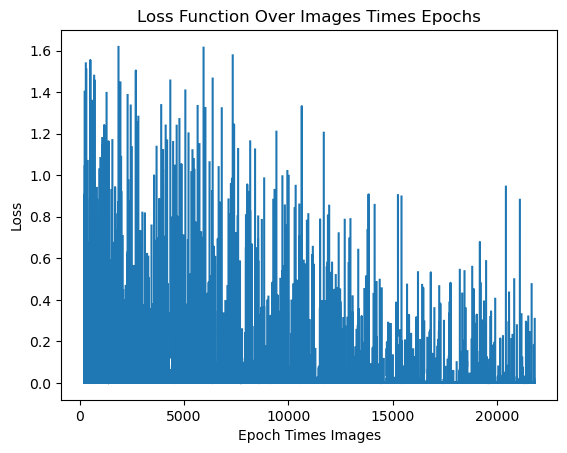

In [ ]:
# Plotting the loss function (simplified)
import matplotlib.pyplot as plt
def plot_loss(loss_history):
    plt.plot(loss_history)
    plt.title('Loss Function Over Images Times Epochs')
    plt.xlabel('Epoch Times Images')
    plt.ylabel('Loss')
    plt.show()

# Assuming loss_history is collected during training
plot_loss(loss_history) 

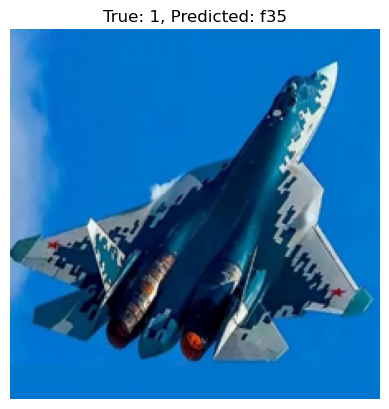

/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_22265/3763185503.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


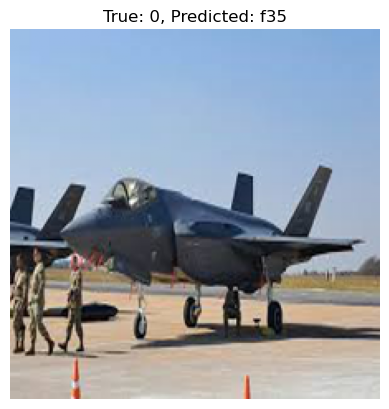

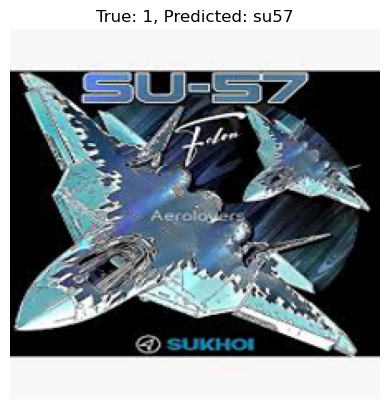

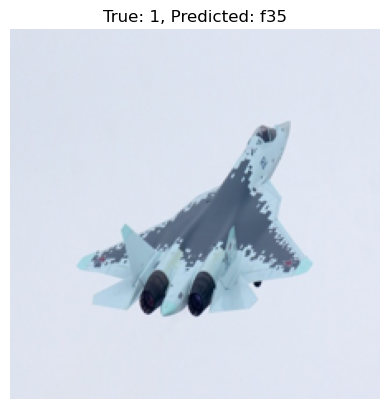

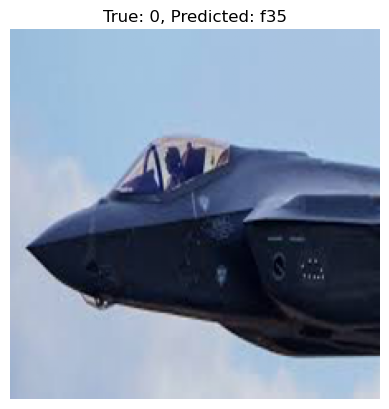

In [131]:
# Print 5 random images from the test set with their predicted and true labels
def display_random_images(test_images, test_labels, weights, bias):
    indices = np.random.choice(len(test_images), 5, replace=False)
    for idx in indices:
        img = test_images[idx]
        label = test_labels[idx]
        input_vector = img.flatten()
        output = sigmoid(np.dot(input_vector, weights) + bias)
        predicted_label = 1 if output >= 0.5 else 0
        plt.imshow(img)
        predicted_class = 'f35' if predicted_label == 0 else 'su57'
        plt.title(f"True: {label}, Predicted: {predicted_class}")
        plt.axis('off')
        plt.show()

display_random_images(test_images, test_labels, weights, bias)

### Step 3
Aumentar el número de neuronas y de capas ocultas. Ver si mejora la predicción.

In [201]:
def train_nn_with_hidden_layers(train_images, train_labels):
    input_size = train_images[0].flatten().shape[0]
    hidden_layer1_size = 32  
    hidden_layer2_size = 16  
    hidden_layer3_size = 8
    output_size = 1
    
    # Initialize weights
    weights_input_hidden1 = np.random.randn(input_size, hidden_layer1_size) * 0.01
    bias_hidden1 = np.zeros(hidden_layer1_size)
    weights_hidden1_hidden2 = np.random.randn(hidden_layer1_size, hidden_layer2_size) * 0.01
    bias_hidden2 = np.zeros(hidden_layer2_size)
    weights_hidden2_hidden3 = np.random.randn(hidden_layer2_size, hidden_layer3_size) * 0.01
    bias_hidden3 = np.zeros(hidden_layer3_size)
    weights_hidden3_output = np.random.randn(hidden_layer3_size, output_size) * 0.01
    bias_output = np.zeros(output_size)
    
    loss_history = []
    accuracy_history = []
    learning_rate = 0.01
    
    for epoch in range(5):
        epoch_loss = 0.0  # Initialize as float, not array
        correct = 0
        for img, label in zip(train_images, train_labels):
            input_vector = img.flatten()
            
            # Forward pass
            h1 = sigmoid(np.dot(input_vector, weights_input_hidden1) + bias_hidden1)
            h2 = sigmoid(np.dot(h1, weights_hidden1_hidden2) + bias_hidden2)
            h3 = sigmoid(np.dot(h2, weights_hidden2_hidden3) + bias_hidden3)
            output = sigmoid(np.dot(h3, weights_hidden3_output) + bias_output)
            
            # Loss for this sample - extract scalar value
            eps = 1e-8
            loss = -(label * np.log(output + eps) + (1-label) * np.log(1-output + eps))
            epoch_loss += loss.item()  # .item() converts 0-dim array to float
            
            # Backward pass
            error = output - label
            
            d_output = error * output * (1-output)
            d_h3 = d_output.dot(weights_hidden3_output.T) * h3 * (1-h3)
            d_h2 = d_h3.dot(weights_hidden2_hidden3.T) * h2 * (1-h2)
            d_h1 = d_h2.dot(weights_hidden1_hidden2.T) * h1 * (1-h1)
            
            # Update weights
            weights_hidden3_output -= learning_rate * np.outer(h3, d_output)
            bias_output -= learning_rate * d_output.flatten()
            weights_hidden2_hidden3 -= learning_rate * np.outer(h2, d_h3)
            bias_hidden3 -= learning_rate * d_h3.flatten()
            weights_hidden1_hidden2 -= learning_rate * np.outer(h1, d_h2)
            bias_hidden2 -= learning_rate * d_h2.flatten()
            weights_input_hidden1 -= learning_rate * np.outer(input_vector, d_h1)
            bias_hidden1 -= learning_rate * d_h1.flatten()
        
        avg_loss = epoch_loss / len(train_images)
        loss_history.append(avg_loss)
        accuracy = correct / len(train_images)
        accuracy_history.append(accuracy)
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")
    
    return (weights_input_hidden1, bias_hidden1, weights_hidden1_hidden2, 
            bias_hidden2, weights_hidden2_hidden3, bias_hidden3, weights_hidden3_output, bias_output, loss_history, accuracy_history)

# Train the NN
(weights_input_hidden1, bias_hidden1, weights_hidden1_hidden2, 
 bias_hidden2, weights_hidden2_hidden3, bias_hidden3, weights_hidden3_output, bias_output, loss_history, accuracy_history) = train_nn_with_hidden_layers(train_images, train_labels)

Epoch 1, Loss: 0.6895, Accuracy: 0.0000
Epoch 2, Loss: 0.6872, Accuracy: 0.0000
Epoch 3, Loss: 0.6869, Accuracy: 0.0000
Epoch 4, Loss: 0.6868, Accuracy: 0.0000
Epoch 5, Loss: 0.6869, Accuracy: 0.0000


In [202]:
# Try to test the NN with hidden layers (simplified)
def test_nn_with_hidden_layers(test_images, test_labels, weights_input_hidden1, bias_hidden1, weights_hidden1_hidden2, bias_hidden2, weights_hidden2_hidden3, bias_hidden3, weights_hidden3_output, bias_output):
    correct_predictions = 0
    for img, label in zip(test_images, test_labels):
        input_vector = img.flatten()
        hidden_layer1_output = sigmoid(np.dot(input_vector, weights_input_hidden1) + bias_hidden1)
        hidden_layer2_output = sigmoid(np.dot(hidden_layer1_output, weights_hidden1_hidden2) + bias_hidden2)
        hidden_layer3_output = sigmoid(np.dot(hidden_layer2_output, weights_hidden2_hidden3) + bias_hidden3)
        output = sigmoid(np.dot(hidden_layer3_output, weights_hidden3_output) + bias_output)
        predicted_label = 1 if output >= 0.5 else 0
        if predicted_label == label:
            correct_predictions += 1
    accuracy = correct_predictions / len(test_labels)
    return accuracy

# Print accuracy for the test set
accuracy = test_nn_with_hidden_layers(test_images, test_labels, weights_input_hidden1, bias_hidden1, weights_hidden1_hidden2, bias_hidden2, weights_hidden2_hidden3, bias_hidden3, weights_hidden3_output, bias_output)
print("Test accuracy with hidden layers:", accuracy)
# Print accuracy for the training set as well to check for overfitting
train_accuracy = test_nn_with_hidden_layers(train_images, train_labels, weights_input_hidden1, bias_hidden1, weights_hidden1_hidden2, bias_hidden2, weights_hidden2_hidden3, bias_hidden3, weights_hidden3_output, bias_output)
print("Train accuracy with hidden layers:", train_accuracy)

Test accuracy with hidden layers: 0.5545454545454546
Train accuracy with hidden layers: 0.5596330275229358


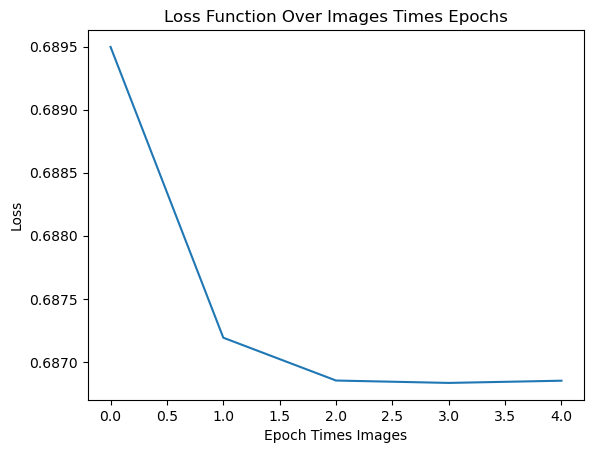

In [203]:
# Plotting the loss function for the NN with hidden layers
plot_loss(loss_history)

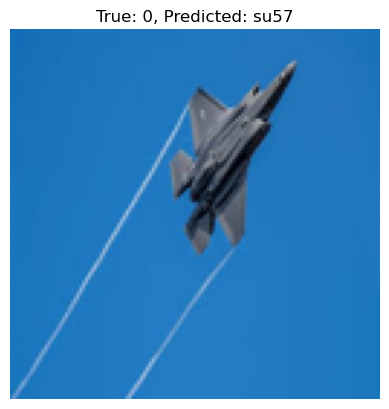

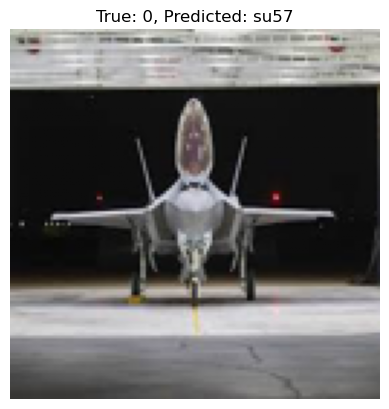

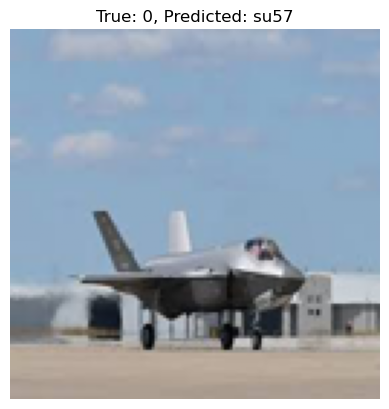

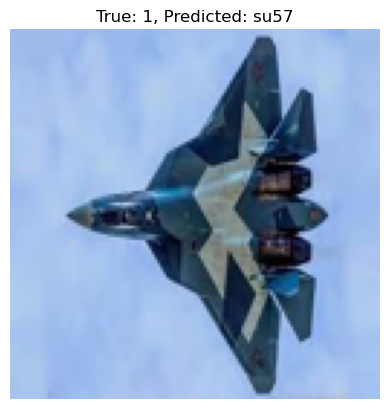

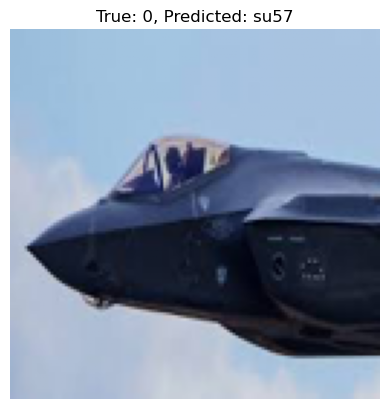

In [204]:
# Print 5 random images from the test set with their predicted and true labels for the NN with hidden layers
def display_random_images_with_hidden_layers(test_images, test_labels, weights_input_hidden1, bias_hidden1, weights_hidden1_hidden2, bias_hidden2, weights_hidden2_hidden3, bias_hidden3, weights_hidden3_output, bias_output):
    indices = np.random.choice(len(test_images), 5, replace=False)
    for idx in indices:
        img = test_images[idx]
        label = test_labels[idx]
        input_vector = img.flatten()
        hidden_layer1_output = sigmoid(np.dot(input_vector, weights_input_hidden1) + bias_hidden1)
        hidden_layer2_output = sigmoid(np.dot(hidden_layer1_output, weights_hidden1_hidden2) + bias_hidden2)
        hidden_layer3_output = sigmoid(np.dot(hidden_layer2_output, weights_hidden2_hidden3) + bias_hidden3)
        output = sigmoid(np.dot(hidden_layer3_output, weights_hidden3_output) + bias_output)
        predicted_label = 1 if output >= 0.5 else 0
        plt.imshow(img)
        predicted_class = 'f35' if predicted_label == 0 else 'su57'
        plt.title(f"True: {label}, Predicted: {predicted_class}")
        plt.axis('off')
        plt.show()

display_random_images_with_hidden_layers(test_images, test_labels, weights_input_hidden1, bias_hidden1, weights_hidden1_hidden2, bias_hidden2, weights_hidden2_hidden3, bias_hidden3, weights_hidden3_output, bias_output)